# Библиотека Pandas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Объекты DataFrame и Series

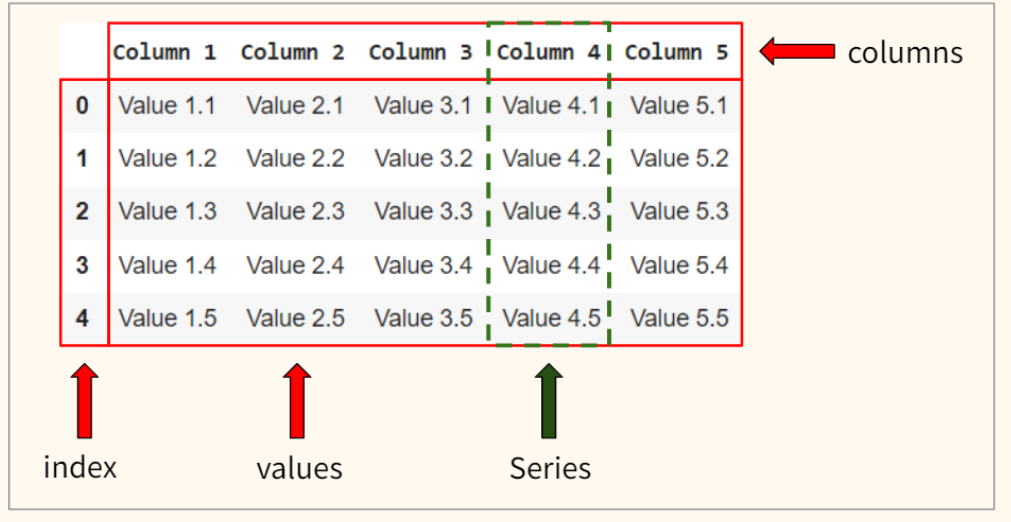

### Создание датафрейма

**Способ 1**. Создание датафрейма из файла

In [2]:
# функция read_csv() распознает zip-архивы,
# в архиве может содержаться только один файл
csv_zip = pd.read_csv('train.zip')
csv_zip.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [3]:
# импортируем данные в формате Excel, указав номер листа, который хотим использовать
excel_data = pd.read_excel('iris.xlsx', sheet_name = 0)
excel_data.head(3)

,Petal_width,Petal_length,Sepal_width,Sepal_length,Species_name
0,0.2,1.4,3.5,5.1,Setosa
1,0.2,1.4,3.0,4.9,Setosa
2,0.2,1.3,3.2,4.7,Setosa


In [4]:
# импортируем таблицу со страницы про мировое население в Википедии
# в параметре match мы передаем ключевые слова, которые помогут найти нужную таблицу
html_data = pd.read_html('https://en.wikipedia.org/wiki/World_population',
                         match = 'World population')

In [5]:
# мы получили пять результатов
len(html_data)

5

In [6]:
# посмотрим на первый результат
html_data[0]

,Population,1,2,3,4,5,6,7,8,9,10
0,Year,1804,1927,1960,1974,1987,1999,2011,2022,2037,2057
1,Years elapsed,"200,000+",123,33,14,13,12,12,11,15,20


**Способ 2**. Подключение к базе данных SQL

In [7]:
# импортируем модуль sqlite3 для работы с базой данных SQL
import sqlite3 as sql

# создадим соединение с базой данных chinook
conn = sql.connect('chinook.db')

# выберем все строки из таблицы tracks
sql_data = pd.read_sql('SELECT * FROM tracks;', conn) # vs. read_sql_query

# посмотрим на результат
sql_data.head(3)

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,None,342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99


**Способ 3**. Создание датафрейма из словаря

In [8]:
# создадим несколько списков и массивов Numpy с информацией о семи странах мира
country = np.array(['China', 'Vietnam', 'United Kingdom', 'Russia', 'Argentina', 'Bolivia', 'South Africa'])
capital = ['Beijing', 'Hanoi', 'London', 'Moscow', 'Buenos Aires', 'Sucre', 'Pretoria']
population = [1400, 97, 67, 144, 45, 12, 59] # млн. человек
area = [9.6, 0.3, 0.2, 17.1, 2.8, 1.1, 1.2] # млн. кв. км.
sea = [1] * 5 + [0, 1] # выход к морю (в этом списке его нет только у Боливии)

In [9]:
sea

[1, 1, 1, 1, 1, 0, 1]

In [10]:
# создадим пустой словарь
countries_dict = {}

# превратим эти списки в значения словаря,
# одновременно снабдив необходимыми ключами
countries_dict['country'] = country
countries_dict['capital'] = capital
countries_dict['population'] = population
countries_dict['area'] = area
countries_dict['sea'] = sea

In [11]:
# посмотрим на результат
# countries_dict

In [12]:
# создадим датафрейм
countries = pd.DataFrame(countries_dict)
countries

,country,capital,population,area,sea
0,China,Beijing,1400,9.6,1
1,Vietnam,Hanoi,97,0.3,1
2,United Kingdom,London,67,0.2,1
3,Russia,Moscow,144,17.1,1
4,Argentina,Buenos Aires,45,2.8,1
5,Bolivia,Sucre,12,1.1,0
6,South Africa,Pretoria,59,1.2,1


**Способ 4**. Создание датафрейма из 2D массива Numpy

In [13]:
# внешнее измерение будет столбцами, внутренее - строками
arr = np.array([[1, 1, 1],
                [2, 2, 2],
                [3, 3, 3]])

pd.DataFrame(arr)

,0,1,2
0,1,1,1
1,2,2,2
2,3,3,3


### Структура и свойства датафрейма

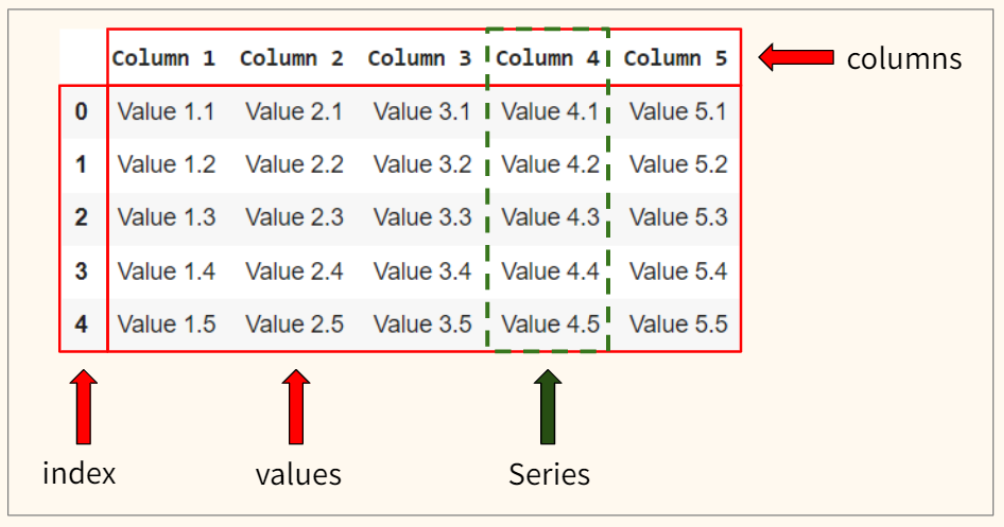

In [14]:
# через атрибут columns можно посмотреть название столбцов
countries.columns

Index(['country', 'capital', 'population', 'area', 'sea'], dtype='object')

In [15]:
# атрибут index показывает, каким образом идентифицируются строки
countries.index

RangeIndex(start=0, stop=7, step=1)

In [16]:
# через values мы видим сами значения
countries.values

array([['China', 'Beijing', 1400, 9.6, 1],
       ['Vietnam', 'Hanoi', 97, 0.3, 1],
       ['United Kingdom', 'London', 67, 0.2, 1],
       ['Russia', 'Moscow', 144, 17.1, 1],
       ['Argentina', 'Buenos Aires', 45, 2.8, 1],
       ['Bolivia', 'Sucre', 12, 1.1, 0],
       ['South Africa', 'Pretoria', 59, 1.2, 1]], dtype=object)

In [17]:
# выведем описание индекса датафрейма через атрибут axes[0]
countries.axes[0]

RangeIndex(start=0, stop=7, step=1)

In [18]:
# axes[1] выводит названия столбцов
countries.axes[1]

Index(['country', 'capital', 'population', 'area', 'sea'], dtype='object')

In [19]:
# также мы можем посмотреть количество измерений, размерность и общее количество элементов
countries.ndim, countries.shape, countries.size

(2, (7, 5), 35)

In [20]:
# атрибут dtypes выдает типы данных каждого столбца
countries.dtypes

country        object
capital        object
population      int64
area          float64
sea             int64
dtype: object

In [21]:
# также можно посмотреть объем занимаемой памяти по столбцам в байтах
countries.memory_usage()

Index         128
country        56
capital        56
population     56
area           56
sea            56
dtype: int64

### Индекс

#### Присвоение индекса

In [22]:
# в датафрейме можно задать собственный индекс (например, коды стран)
custom_index = ['CN', 'VN', 'GB', 'RU', 'AR', 'BO', 'ZA']

In [23]:
# для этого при создании датафрейма используется параметр index
countries = pd.DataFrame(countries_dict,
                         index = custom_index)

countries

,country,capital,population,area,sea
CN,China,Beijing,1400,9.6,1
VN,Vietnam,Hanoi,97,0.3,1
GB,United Kingdom,London,67,0.2,1
RU,Russia,Moscow,144,17.1,1
AR,Argentina,Buenos Aires,45,2.8,1
BO,Bolivia,Sucre,12,1.1,0
ZA,South Africa,Pretoria,59,1.2,1


In [24]:
# этот индекс можно сбросить
# параметр inplace = True сохраняет изменения
countries.reset_index(inplace = True)
countries

,index,country,capital,population,area,sea
0,CN,China,Beijing,1400,9.6,1
1,VN,Vietnam,Hanoi,97,0.3,1
2,GB,United Kingdom,London,67,0.2,1
3,RU,Russia,Moscow,144,17.1,1
4,AR,Argentina,Buenos Aires,45,2.8,1
5,BO,Bolivia,Sucre,12,1.1,0
6,ZA,South Africa,Pretoria,59,1.2,1


In [25]:
# прошлый индекс стал отдельным столбцом
# его снова можно сделать индексом через метод .set_index()
countries.set_index('index', inplace = True)
countries

,country,capital,population,area,sea
index,,,,,
CN,China,Beijing,1400,9.6,1
VN,Vietnam,Hanoi,97,0.3,1
GB,United Kingdom,London,67,0.2,1
RU,Russia,Moscow,144,17.1,1
AR,Argentina,Buenos Aires,45,2.8,1
BO,Bolivia,Sucre,12,1.1,0
ZA,South Africa,Pretoria,59,1.2,1


In [26]:
# снова сбросим индекс, но на этот раз не будем делать его отдельным столбцом
# через drop = True
countries.reset_index(drop = True, inplace = True)
countries

,country,capital,population,area,sea
0,China,Beijing,1400,9.6,1
1,Vietnam,Hanoi,97,0.3,1
2,United Kingdom,London,67,0.2,1
3,Russia,Moscow,144,17.1,1
4,Argentina,Buenos Aires,45,2.8,1
5,Bolivia,Sucre,12,1.1,0
6,South Africa,Pretoria,59,1.2,1


In [27]:
# собственный индекс можно создать, просто поместив новые значения в атрибут index
countries.index = custom_index
countries

,country,capital,population,area,sea
CN,China,Beijing,1400,9.6,1
VN,Vietnam,Hanoi,97,0.3,1
GB,United Kingdom,London,67,0.2,1
RU,Russia,Moscow,144,17.1,1
AR,Argentina,Buenos Aires,45,2.8,1
BO,Bolivia,Sucre,12,1.1,0
ZA,South Africa,Pretoria,59,1.2,1


#### Многоуровневый индекс

In [28]:
# создадим список из кортежей с названием континента и кодом страны
rows = [('Asia', 'CN'),
        ('Asia', 'VN'),
        ('Europe', 'GB'),
        ('Europe', 'RU'),
        ('S. America', 'AR'),
        ('S. America', 'BO'),
        ('Africa', 'ZA')]

# в столбцах название страны и столицы мы объединим в категорию names
# а размер населения, площадь и выход к морю в data
cols = [('names', 'country'),
        ('names', 'capital'),
        ('data', 'population'),
        ('data', 'area'),
        ('data', 'sea')]

# создадим многоуровневый индекс для строк
# индексам присвоим названия через names = ['region', 'code']
custom_multindex = pd.MultiIndex.from_tuples(rows, names = ['region', 'code'])

# сделаем то же самое для столбцов
custom_multicols = pd.MultiIndex.from_tuples(cols)

# передадим эти индексы в атрибуты index и columns датафрейма
countries.index = custom_multindex
countries.columns = custom_multicols

# посмотрим на результат
countries

names                     data          
                        country       capital population  area sea
region     code                                                   
Asia       CN             China       Beijing       1400   9.6   1
           VN           Vietnam         Hanoi         97   0.3   1
Europe     GB    United Kingdom        London         67   0.2   1
           RU            Russia        Moscow        144  17.1   1
S. America AR         Argentina  Buenos Aires         45   2.8   1
           BO           Bolivia         Sucre         12   1.1   0
Africa     ZA      South Africa      Pretoria         59   1.2   1

In [29]:
# вернемся к обычному индексу и названиям столбцов
custom_cols = ['country', 'capital', 'population', 'area', 'sea']

countries.index = custom_index
countries.columns = custom_cols

countries

,country,capital,population,area,sea
CN,China,Beijing,1400,9.6,1
VN,Vietnam,Hanoi,97,0.3,1
GB,United Kingdom,London,67,0.2,1
RU,Russia,Moscow,144,17.1,1
AR,Argentina,Buenos Aires,45,2.8,1
BO,Bolivia,Sucre,12,1.1,0
ZA,South Africa,Pretoria,59,1.2,1


### Преобразование в другие форматы

In [30]:
# получившийся датафрейм можно преобразовать в словарь
print(countries.to_dict())

{'country': {'CN': 'China', 'VN': 'Vietnam', 'GB': 'United Kingdom', 'RU': 'Russia', 'AR': 'Argentina', 'BO': 'Bolivia', 'ZA': 'South Africa'}, 'capital': {'CN': 'Beijing', 'VN': 'Hanoi', 'GB': 'London', 'RU': 'Moscow', 'AR': 'Buenos Aires', 'BO': 'Sucre', 'ZA': 'Pretoria'}, 'population': {'CN': 1400, 'VN': 97, 'GB': 67, 'RU': 144, 'AR': 45, 'BO': 12, 'ZA': 59}, 'area': {'CN': 9.6, 'VN': 0.3, 'GB': 0.2, 'RU': 17.1, 'AR': 2.8, 'BO': 1.1, 'ZA': 1.2}, 'sea': {'CN': 1, 'VN': 1, 'GB': 1, 'RU': 1, 'AR': 1, 'BO': 0, 'ZA': 1}}


In [31]:
# или массив Numpy
countries.to_numpy()

array([['China', 'Beijing', 1400, 9.6, 1],
       ['Vietnam', 'Hanoi', 97, 0.3, 1],
       ['United Kingdom', 'London', 67, 0.2, 1],
       ['Russia', 'Moscow', 144, 17.1, 1],
       ['Argentina', 'Buenos Aires', 45, 2.8, 1],
       ['Bolivia', 'Sucre', 12, 1.1, 0],
       ['South Africa', 'Pretoria', 59, 1.2, 1]], dtype=object)

In [32]:
# или поместить в файл (появится в "Сессионном хранилище")
# по умолчанию, индекс также станет частью .csv файла
# параметр index = False позволит этого избежать
countries.to_csv('countries.csv', index = False)

In [33]:
# столбец (Series) можно преобразовать в список, датафрейм - нельзя
print(countries.country.to_list())

['China', 'Vietnam', 'United Kingdom', 'Russia', 'Argentina', 'Bolivia', 'South Africa']


### Создание Series

Создание Series из списка

In [34]:
# создадим список с названиями стран
country_list = ['China', 'South Africa', 'United Kingdom', 'Russia', 'Argentina', 'Vietnam', 'Australia']

In [35]:
# передадим его в функцию pd.Series()
country_Series = pd.Series(country_list)
country_Series

0             China
1      South Africa
2    United Kingdom
3            Russia
4         Argentina
5           Vietnam
6         Australia
dtype: object

In [36]:
# по числовому индексу можно получить доступ к первому элементу
country_Series[0]

'China'

Создание Series из словаря

In [37]:
# создадим словарь с кодами и названиями стран
country_dict = {'CN' : 'China',
                'ZA' : 'South Africa',
                'GB' : 'United Kingdom',
                'RU' : 'Russia',
                'AR' : 'Argentina',
                'VN' : 'Vietnam',
                'AU' : 'Australia'
                }

In [38]:
# передадим его в функцию pd.Series(), ключи в этом случае станут индексом
country_Series = pd.Series(country_dict)
country_Series

CN             China
ZA      South Africa
GB    United Kingdom
RU            Russia
AR         Argentina
VN           Vietnam
AU         Australia
dtype: object

In [39]:
# теперь для доступа к элементам можно использовать коды стран
country_Series['AU']

'Australia'

## Доступ к строкам и столбцам

### Циклы в датафрейме

In [40]:
# мы можем получить доступ к названиям столбцов с помощью цикла for
for column in countries:
  print(column)

country
capital
population
area
sea


In [41]:
# метод .iterrows() возвращает индекс строки и ее содержимое в формате Series
for index, row in countries.iterrows():
  print(index)
  print(row)
  print('...')
  print(type(row))
  break

CN
country         China
capital       Beijing
population       1400
area              9.6
sea                 1
Name: CN, dtype: object
...
<class 'pandas.core.series.Series'>


In [42]:
# получить доступ к данным одной строки можно по индексу Series
for _, row in countries.iterrows():
  # например, сформируем вот такое предложение
  print(row['capital'] + ' is the capital of ' + row['country'])
  break

Beijing is the capital of China


### Доступ к столбцам

In [43]:
# в отличие от Series, в датафрейме через квадратные скобки
# мы получаем доступ к столбцам
countries['capital']

CN         Beijing
VN           Hanoi
GB          London
RU          Moscow
AR    Buenos Aires
BO           Sucre
ZA        Pretoria
Name: capital, dtype: object

In [44]:
# можно также указать название столбца через точку,
# однако в этом случае название не должно содержать пробелов
countries.capital

CN         Beijing
VN           Hanoi
GB          London
RU          Moscow
AR    Buenos Aires
BO           Sucre
ZA        Pretoria
Name: capital, dtype: object

In [45]:
# отдельные столбцы в датафрейме имеют тип данных Series
type(countries.capital)

pandas.core.series.Series

In [46]:
# одинарные скобки дают Series, двойные - датафрейм
# логика в том, что внутрениие скобки - это список, внешние - оператор индексации
countries[['capital']]

,capital
CN,Beijing
VN,Hanoi
GB,London
RU,Moscow
AR,Buenos Aires
BO,Sucre
ZA,Pretoria


In [47]:
# так мы можем получить доступ к нескольким столбцам
countries[['capital', 'area']]

,capital,area
CN,Beijing,9.6
VN,Hanoi,0.3
GB,London,0.2
RU,Moscow,17.1
AR,Buenos Aires,2.8
BO,Sucre,1.1
ZA,Pretoria,1.2


In [48]:
# доступ к столбцам можно также получить через метод .filter()
# с параметром items
countries.filter(items = ['capital', 'population'])

,capital,population
CN,Beijing,1400
VN,Hanoi,97
GB,London,67
RU,Moscow,144
AR,Buenos Aires,45
BO,Sucre,12
ZA,Pretoria,59


### Доступ к строкам

In [49]:
# доступ к строкам можно получить через срез индекса
# выведем строки со второй по пятую (не включительно)
countries[1:5]

,country,capital,population,area,sea
VN,Vietnam,Hanoi,97,0.3,1
GB,United Kingdom,London,67,0.2,1
RU,Russia,Moscow,144,17.1,1
AR,Argentina,Buenos Aires,45,2.8,1


### Методы `.loc[]` и `.iloc[]`

Метод `.loc[]`

In [50]:
# метод .loc[] позволяет получить доступ к строкам и столбцам через их названия (label-based location)
# например, выведем первые три строки и первые три столбца датафрейма
countries.loc[['CN', 'RU', 'VN'], ['capital', 'population', 'area']]

,capital,population,area
CN,Beijing,1400,9.6
RU,Moscow,144,17.1
VN,Hanoi,97,0.3


In [51]:
# через двоеточие, как и в Numpy, мы можем вывести все строки или все столбцы
countries.loc[:, ['capital', 'population', 'area']]

,capital,population,area
CN,Beijing,1400,9.6
VN,Hanoi,97,0.3
GB,London,67,0.2
RU,Moscow,144,17.1
AR,Buenos Aires,45,2.8
BO,Sucre,12,1.1
ZA,Pretoria,59,1.2


In [52]:
# метод .loc[] также поддерживает значения Boolean
# выведем последний столбец
countries.loc[:, [False, False, False, False, True]]

,sea
CN,1
VN,1
GB,1
RU,1
AR,1
BO,0
ZA,1


Метод `.get_loc()`

In [53]:
# атрибут index и метод .get_loc() позволяют вывести порядковый номер строки (начиная с нуля)
countries.index.get_loc('RU')

3

In [54]:
# атрибут columns и метод .get_loc() позволяют вывести порядковый номер столбца (также начиная с нуля)
countries.columns.get_loc('country')

0

Метод `.iloc[]`

In [55]:
# метод .iloc[] позволяет получить доступ к строкам и столбцам по числовому индексу (integer-based location)
countries.iloc[[0, 3, 5], [0, 1, 2]]

,country,capital,population
CN,China,Beijing,1400
RU,Russia,Moscow,144
BO,Bolivia,Sucre,12


In [56]:
# в методе .iloc[] можно использовать срезы
# выведем первые три строки и последние два столбца
countries.iloc[:3, -2:]

,area,sea
CN,9.6,1
VN,0.3,1
GB,0.2,1


In [57]:
# удобно использовать доступ к столбцам через двойные квадратные скобки,
# а к строкам через числовой индекс и метод .iloc[]
countries[['population', 'area']].iloc[[0, 3]]

,population,area
CN,1400,9.6
RU,144,17.1


Доступ по многоуровневому индексу

In [58]:
# вновь создадим датафрейм с многоуровневым индексом по строкам и столбцам
countries.index = custom_multindex
countries.columns = custom_multicols

countries

names                     data          
                        country       capital population  area sea
region     code                                                   
Asia       CN             China       Beijing       1400   9.6   1
           VN           Vietnam         Hanoi         97   0.3   1
Europe     GB    United Kingdom        London         67   0.2   1
           RU            Russia        Moscow        144  17.1   1
S. America AR         Argentina  Buenos Aires         45   2.8   1
           BO           Bolivia         Sucre         12   1.1   0
Africa     ZA      South Africa      Pretoria         59   1.2   1

In [59]:
# для доступа к первой строке передадим методу .loc[] двойной индекс
countries.loc['Asia', 'CN']

names  country         China
       capital       Beijing
data   population       1400
       area              9.6
       sea                 1
Name: (Asia, CN), dtype: object

In [60]:
# мы также можем передать значения в форме кортежей для строк и столбцов
countries.loc[('Asia', 'CN'), [('data', 'population'), ('data', 'area'), ('data', 'sea')]]

data  population    1400.0
      area             9.6
      sea              1.0
Name: (Asia, CN), dtype: float64

In [61]:
# доступ к строкам можно получить, указав внутри кортежа название региона и список с кодами стран
countries.loc[('Asia', ['CN', 'VN']), :]

names                data         
             country  capital population area sea
region code                                      
Asia   CN      China  Beijing       1400  9.6   1
       VN    Vietnam    Hanoi         97  0.3   1

In [62]:
# можно указать только регион, тогда мы получим все находящиеся в нем страны
countries.loc[('Asia'), :]

names                data         
      country  capital population area sea
code                                      
CN      China  Beijing       1400  9.6   1
VN    Vietnam    Hanoi         97  0.3   1

In [63]:
# аналогично можно получить доступ к столбцам
countries.loc[:, [('names', 'country'), ('data', 'population')]]

names       data
                        country population
region     code                           
Asia       CN             China       1400
           VN           Vietnam         97
Europe     GB    United Kingdom         67
           RU            Russia        144
S. America AR         Argentina         45
           BO           Bolivia         12
Africa     ZA      South Africa         59

In [64]:
# метод .iloc[] игнорирует структуру многоуровневого индекса и использует простой числовой индекс
# получим доступ к четвертой строке и третьему, четвертому и пятому столбцам
countries.iloc[3, [2, 3, 4]]

data  population    144.0
      area           17.1
      sea             1.0
Name: (Europe, RU), dtype: float64

### Метод `.xs()`

In [65]:
# метод .xs() (cross-section, срез) позволяет получить доступ к определенному уровню многоуровневого индекса
# например, выберем Европу из уровня region (axis = 0 указывает, что мы берем строки)
countries.xs('Europe', level = 'region', axis = 0)

names               data          
             country capital population  area sea
code                                             
GB    United Kingdom  London         67   0.2   1
RU            Russia  Moscow        144  17.1   1

In [66]:
# выберем столбцы на первом [0] и втором [1] уровнях индекса
# параметр axis = 1 указывает на то, что мы имеем дело со столбцами
countries.xs(('names', 'country'), level = [0, 1], axis = 1)

names
                        country
region     code                
Asia       CN             China
           VN           Vietnam
Europe     GB    United Kingdom
           RU            Russia
S. America AR         Argentina
           BO           Bolivia
Africa     ZA      South Africa

In [67]:
# в данном случае level не обязателен
countries.xs('Europe', axis = 0).xs(('names'), axis = 1)

,country,capital
code,,
GB,United Kingdom,London
RU,Russia,Moscow


In [68]:
# вернем датафрейму одноуровневый индекс
countries.index = custom_index
countries.columns = custom_cols

# посмотрим на исходный датафрейм
countries

,country,capital,population,area,sea
CN,China,Beijing,1400,9.6,1
VN,Vietnam,Hanoi,97,0.3,1
GB,United Kingdom,London,67,0.2,1
RU,Russia,Moscow,144,17.1,1
AR,Argentina,Buenos Aires,45,2.8,1
BO,Bolivia,Sucre,12,1.1,0
ZA,South Africa,Pretoria,59,1.2,1


### Метод `.at[]`

In [69]:
# подходит только для получения/записи одного значения
countries.at['CN', 'capital']

'Beijing'

### Фильтры

#### Логическая маска

In [70]:
# создадим логическую маску для стран с населением больше миллиарда человек
countries.population > 1000

CN     True
VN    False
GB    False
RU    False
AR    False
BO    False
ZA    False
Name: population, dtype: bool

In [71]:
# применим логическую маску к исходному датафрейму
countries[countries.population > 1000]

,country,capital,population,area,sea
CN,China,Beijing,1400,9.6,1


In [72]:
# отфильтруем датафрейм по критериям численности населения и площади
countries[(countries.population > 50) & (countries.area < 2)]

,country,capital,population,area,sea
VN,Vietnam,Hanoi,97,0.3,1
GB,United Kingdom,London,67,0.2,1
ZA,South Africa,Pretoria,59,1.2,1


In [73]:
# еще один вариант синтаксиса
# вначале создаем нужные нам маски
population_mask = countries.population > 70
area_mask = countries.population < 50

# затем объединяем их по необходимым условиям (в данном случае ИЛИ)
mask = population_mask | area_mask
# и применяем маску к исходному датафрейму
countries[mask]

,country,capital,population,area,sea
CN,China,Beijing,1400,9.6,1
VN,Vietnam,Hanoi,97,0.3,1
RU,Russia,Moscow,144,17.1,1
AR,Argentina,Buenos Aires,45,2.8,1
BO,Bolivia,Sucre,12,1.1,0


#### Метод `.query()`

In [74]:
# метод .query() позволяет задавать условие фильтраци "своими словами"
countries.query('population > 50 and area < 2')

,country,capital,population,area,sea
VN,Vietnam,Hanoi,97,0.3,1
GB,United Kingdom,London,67,0.2,1
ZA,South Africa,Pretoria,59,1.2,1


In [75]:
# обратите внимание на использование двойных и одинарных кавычек
countries.query("country == 'United Kingdom'")

,country,capital,population,area,sea
GB,United Kingdom,London,67,0.2,1


#### Другие способы фильтрации

In [76]:
# с помощью метода .isin()
# найдем строки, в которых в столбце capital присутствуют следующие значения
keyword_list = ['Beijing', 'Moscow', 'Hanoi']

countries[countries.capital.isin(keyword_list)]

,country,capital,population,area,sea
CN,China,Beijing,1400,9.6,1
VN,Vietnam,Hanoi,97,0.3,1
RU,Russia,Moscow,144,17.1,1


In [77]:
# похожим образом можно использовать метод .startswith()
# например, для нахождения стран, НЕ начинающихся с буквы "A"
countries[ ~ countries.country.str.startswith('A')]

,country,capital,population,area,sea
CN,China,Beijing,1400,9.6,1
VN,Vietnam,Hanoi,97,0.3,1
GB,United Kingdom,London,67,0.2,1
RU,Russia,Moscow,144,17.1,1
BO,Bolivia,Sucre,12,1.1,0
ZA,South Africa,Pretoria,59,1.2,1


In [78]:
# метод .nlargest() позволяет найти
# строки с наибольшим значением в определенном столбце
# метод .nsmallest() выполняет обратное действие
countries.nlargest(3, 'population')

,country,capital,population,area,sea
CN,China,Beijing,1400,9.6,1
RU,Russia,Moscow,144,17.1,1
VN,Vietnam,Hanoi,97,0.3,1


In [79]:
# метод .argmax() выводит индекс строки с наибольшим значением,
# метод .argmin() выполняет то же самое действие, но для наименьшего значения
countries.area.argmax()

3

In [80]:
# посмотрим, какой стране соответствует этот индекс
countries.iloc[[countries.area.argmax()]]

,country,capital,population,area,sea
RU,Russia,Moscow,144,17.1,1


In [81]:
# помня, что в метод .loc[] можно передать тип Boolean,
# зададим критерий для строк датафрейма
countries.loc[countries.population > 90, :]

,country,capital,population,area,sea
CN,China,Beijing,1400,9.6,1
VN,Vietnam,Hanoi,97,0.3,1
RU,Russia,Moscow,144,17.1,1


In [82]:
# метод .filter() с параметром like позволяет искать совпадения в
# индексе (axis = 0) или столбцах (axis = 1)
countries.filter(like = 'ZA', axis = 0)

,country,capital,population,area,sea
ZA,South Africa,Pretoria,59,1.2,1


### Сортировка!!!!!

In [83]:
# выполним сортировку по столбцу population, не сохраняя изменений,
# в возрастающем порядке (значение по умолчанию)
countries.sort_values(by = 'population', inplace = False, ascending = True)

,country,capital,population,area,sea
BO,Bolivia,Sucre,12,1.1,0
AR,Argentina,Buenos Aires,45,2.8,1
ZA,South Africa,Pretoria,59,1.2,1
GB,United Kingdom,London,67,0.2,1
VN,Vietnam,Hanoi,97,0.3,1
RU,Russia,Moscow,144,17.1,1
CN,China,Beijing,1400,9.6,1


In [84]:
# теперь отсортируем по двум столбцам в нисходящем порядке
countries.sort_values(by = ['area', 'population'], inplace = False, ascending = False)

,country,capital,population,area,sea
RU,Russia,Moscow,144,17.1,1
CN,China,Beijing,1400,9.6,1
AR,Argentina,Buenos Aires,45,2.8,1
ZA,South Africa,Pretoria,59,1.2,1
BO,Bolivia,Sucre,12,1.1,0
VN,Vietnam,Hanoi,97,0.3,1
GB,United Kingdom,London,67,0.2,1


In [85]:
# также можно отсортировать по индексу
countries.sort_index()

,country,capital,population,area,sea
AR,Argentina,Buenos Aires,45,2.8,1
BO,Bolivia,Sucre,12,1.1,0
CN,China,Beijing,1400,9.6,1
GB,United Kingdom,London,67,0.2,1
RU,Russia,Moscow,144,17.1,1
VN,Vietnam,Hanoi,97,0.3,1
ZA,South Africa,Pretoria,59,1.2,1
